In [6]:
import torch
from torch import nn, optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
from datetime import datetime
import numpy as np
from torch.utils.data import Dataset
from pathlib import Path
import matplotlib.pyplot as plt
import torch.nn.functional as F
from collections import Counter
import json
from itertools import product
import math
import hashlib
import io
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [7]:
SEED = 42
torch.manual_seed(SEED)
torch.set_default_dtype(torch.double)

In [8]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training on device {device}.")

Training on device cpu.


In [9]:
CLASS_COLOURS = ["skyblue", "pink"]
EPOCH_INVESTIGATE_POINTS = [5, 15, 30]

In [10]:
def show_img(img, label) -> None:
    img = img.squeeze().permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()

In [11]:
class CIFAR2(Dataset):
    def __init__(self, data_path: Path):
        self.data_path = data_path
        self.data, self.targets = self.__loaddata__()

        self.transformer = transforms.Compose(
            [
                transforms.ToTensor(),
            ]
        )

    def set_transformer(self, transformer: transforms.Compose):
        self.transformer = transformer

    def __loaddata__(self):
        data = datasets.CIFAR10(root=str(self.data_path), transform=None, download=True)
        targets = np.array(data.targets)
        indices = (targets == 0) | (targets == 2)  # plane, bird

        images, targets = data.data[indices], targets[indices]

        # resample 0 is ok, 2 -> 1
        targets = [1 if t == 2 else t for t in targets]

        return images, targets

    def __getitem__(self, idx) -> tuple[torch.Tensor, int]:
        img, target = self.data[idx], self.targets[idx]
        return self.transformer(img), target

    def __len__(self):
        return len(self.data)

In [58]:
class Preprocessor:
    def __init__(self):
        self.transformer = None
        self.mean = None
        self.std = None

    def fit(self, train_loader):
        mean = 0.0
        std = 0.0
        total_images = 0

        for images, _ in train_loader:
            batch_samples = images.size(0)
            images = images.view(batch_samples, images.size(1), -1)
            mean += images.mean(2).sum(0)
            std += images.std(2).sum(0)
            total_images += batch_samples

        self.mean = mean / total_images
        self.std = std / total_images

        self.transformer = transforms.Compose(
            [transforms.ToTensor(), transforms.Normalize(self.mean, self.std)]
        )
        return self.transformer

    def process(self, data):
        return self.transformer(data)

    def unnormalize(self, img):
        img = img.clone()
        for c in range(img.shape[0]):
            img[c] = img[c] * self.std[c] + self.mean[c]
        return torch.clamp(img, 0, 1)


In [59]:
def load_cifar(
    train_val_split=0.9, data_path="data/", preprocessor: Preprocessor = None
):
    cifar2 = CIFAR2(Path(data_path))

    train_size = int(len(cifar2) * train_val_split)
    val_test_size = len(cifar2) - train_size

    cifar_generator = torch.Generator().manual_seed(SEED)
    train, val_test = random_split(
        cifar2, lengths=[train_size, val_test_size], generator=cifar_generator
    )

    test_val_split = 0.5  # 0.05, 0.05
    val_size = int(len(val_test) * test_val_split)
    test_size = len(val_test) - val_size

    val, test = random_split(
        val_test, lengths=[val_size, test_size], generator=cifar_generator
    )

    batch_size = 32

    # get mean and std from train data only
    train_loader = DataLoader(train, batch_size=batch_size, shuffle=False)
    train_transforms = preprocessor.fit(train_loader)
    cifar2.set_transformer(train_transforms)

    # now cifar2 loads and
    train_loader = DataLoader(train, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


processor = Preprocessor()
train_loader, val_loader, test_loader = load_cifar(preprocessor=processor)


def binary_to_label(targets):
    all_targets = ["plane" if t == 0 else t for t in targets]
    return ["bird" if t == 1 else t for t in all_targets]

/home/henrik/school/inf265_projects/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


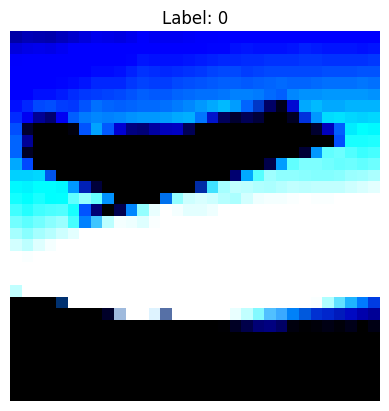

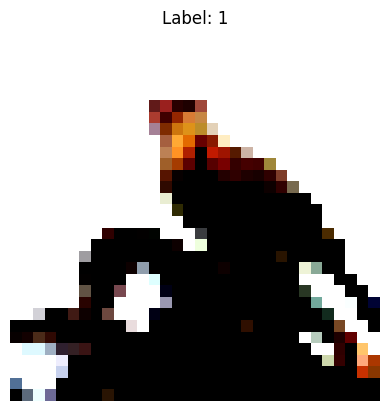

In [14]:
batch = next(iter(train_loader))
imgs, labels = batch
show_img(imgs[0], labels[0])  # plane = label 0
show_img(imgs[3], labels[3])  # bird = label 1

Images have been normalized so they are a little hard for us to understand, but this is good for the computer `:^)`

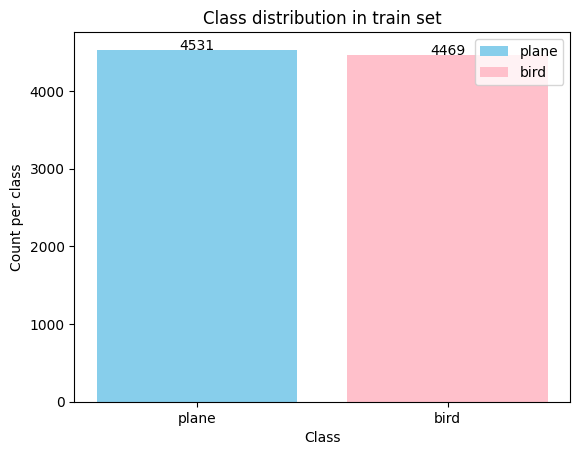

In [15]:
all_targets = torch.cat([label for _, label in train_loader]).tolist()
all_targets = binary_to_label(all_targets)

counts = Counter(all_targets)
plt.bar(
    list(counts.keys()), list(counts.values()), label=counts.keys(), color=CLASS_COLOURS
)
plt.xlabel("Class")
plt.ylabel("Count per class")
plt.title("Class distribution in train set")
for x, y in counts.items():
    plt.text(x, y, f"{y}", ha="center")
plt.legend()
plt.show()

Looks balanced, accuracy is probably an ok performance measure

In [16]:
def compute_accuracy(model, loader):
    """
    From 02_using_nn_seq, and 06_pretrained_network
    """
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device=device) # dtype=torch.double
            labels = labels.to(device=device) # dtype=torch.double

            outputs = model(imgs)
            _, predicted = torch.max(outputs, dim=1)
            total += labels.shape[0]
            correct += int((predicted == labels).sum())

    return correct / total

In [17]:
def compute_confusion_matrix(model, dataset, title):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in dataset:
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, dim=1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    cm_percent = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
    cm_percent = np.nan_to_num(cm_percent)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # all
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["plane", "bird"])
    disp1.plot(ax=axes[0], cmap=plt.cm.Blues, colorbar=False)
    axes[0].set_title(f"Counts: {title}")

    # percentages
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=["plane", "bird"])
    disp2.plot(ax=axes[1], cmap=plt.cm.Blues, colorbar=True, values_format=".1f")
    axes[1].set_title(f"Percentages: {title}")

    plt.tight_layout()
    plt.show()


In [18]:
def train(
    n_epochs,
    optimizer,
    model,
    loss_fn,
    train_loader: DataLoader,
    validation_loader: DataLoader,
):
    n_batch_train = len(train_loader)
    n_batch_val = len(validation_loader)

    losses_train, losses_val = [], []
    train_accuracies, val_accuracies = {}, {}

    model.train()  # set to train mode
    optimizer.zero_grad(set_to_none=True)

    for epoch in range(1, n_epochs + 1):
        loss_train, loss_val = 0.0, 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device) # dtype=torch.double
            labels = labels.to(device=device) # dtype=torch.double

            outputs = model(imgs)

            loss = loss_fn(outputs, labels)
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

            loss_train += loss.item()

        model.eval()  # observe model performance
        with torch.no_grad():
            for val_imgs, val_labels in validation_loader:
                imgs_val = val_imgs.to(device=device) # dtype=torch.double)
                val_labels = val_labels.to(device=device) # dtype=torch.double)
                val_outputs = model(imgs_val)
                val_loss = loss_fn(val_outputs, val_labels)
                loss_val += val_loss.item()

        if epoch in EPOCH_INVESTIGATE_POINTS:
            train_accuracies[epoch] = compute_accuracy(model, train_loader)
            val_accuracies[epoch] = compute_accuracy(model, validation_loader)

        # swap back to train mode
        model.train()

        losses_train.append(loss_train / n_batch_train)
        losses_val.append(loss_val / n_batch_val)

        if epoch == 1 or epoch % 10 == 0:  # TODO add validation loss
            print(
                "{}  |  Epoch {}  |  Training loss {:.3f}".format(
                    datetime.now().time(), epoch, loss_train / n_batch_train
                )
            )
    return losses_train, losses_val, train_accuracies, val_accuracies

In [19]:
class MyMLPBaseLine(nn.Module):
    """
    inp layer: 3072 - 512 relu
    hid layer: 512 - 128 relu
    hid layer: 128 - 32 relu
    out layer: 32 - 2 no activation function
    """

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 32)
        self.fc4 = nn.Linear(32, 2)

    def forward(self, x):
        out = torch.flatten(x, 1)
        out = F.relu(self.fc1(out))
        out = F.relu(self.fc2(out))
        out = F.relu(self.fc3(out))
        out = self.fc4(out)  # final layer
        return out

    def name(self):
        return "MyMLPBaseLine"

In [20]:
# a. Increase the size of a hidden layer (wider)
class MyMLPWide(nn.Module):
    """
    inp layer: 3072 - 512 relu
    hid layer: 512 - 128 relu
    hid layer: 128 - 32 relu
    out layer: 32 - 2 no activation function
    """

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.fc2 = nn.Linear(512, 256)  # increased to 256 from 128
        self.fc3 = nn.Linear(256, 32)  # increased to 256 from 128
        self.fc4 = nn.Linear(32, 2)

    def forward(self, x):
        out = torch.flatten(x, 1)
        out = F.relu(self.fc1(out))
        out = F.relu(self.fc2(out))
        out = F.relu(self.fc3(out))
        out = self.fc4(out)  # final layer
        return out

    def name(self):
        return "MyMLPWide"

In [21]:
# b. Increasing the model depth by adding one or more hidden layers (deeper)
class MyMLPDeep(nn.Module):
    """
    inp layer: 3072 - 512 relu
    hid layer: 512 - 128 relu
    hid layer: 128 - 64 relu
    hid layer: 64 - 32 relu
    out layer: 32 - 2 no activation function
    """

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 64)  # additional layer
        self.fc4 = nn.Linear(64, 32)
        self.fc5 = nn.Linear(32, 2)

    def forward(self, x):
        out = torch.flatten(x, 1)
        out = F.relu(self.fc1(out))
        out = F.relu(self.fc2(out))
        out = F.relu(self.fc3(out))
        out = F.relu(self.fc4(out))
        out = self.fc5(out)
        return out

    def name(self):
        return "MyMLPDeep"

In [22]:
class MyMLPDropout(nn.Module):
    """
    inp layer: 3072 - 512 relu (0.2 dropout)
    hid layer: 512 - 128 relu (0.2 dropout)
    hid layer: 128 - 32 relu (0.2 dropout)
    out layer: 32 - 2 no activation function (no dropout)
    """

    def __init__(self, dropout_rate: float):
        super().__init__()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 32)
        self.fc4 = nn.Linear(32, 2)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        out = torch.flatten(x, 1)
        out = self.dropout(F.relu(self.fc1(out)))
        out = self.dropout(F.relu(self.fc2(out)))
        out = self.dropout(F.relu(self.fc3(out)))
        out = self.fc4(out)
        return out

    def name(self):
        return "MyMLPDropout"

Lets run a quick check to see that everything is in order

In [17]:
model_baseline = MyMLPBaseLine().to(device)

In [18]:
optimizer = optim.SGD(model_baseline.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

train_losses, validation_losses, train_accuracies_base, val_accuracies_base = train(
    n_epochs=30,
    optimizer=optimizer,
    model=model_baseline,
    loss_fn=loss_fn,
    train_loader=train_loader,
    validation_loader=val_loader,
)

13:19:48.135863  |  Epoch 1  |  Training loss 0.541
13:20:05.082616  |  Epoch 10  |  Training loss 0.212
13:20:23.204779  |  Epoch 20  |  Training loss 0.087
13:20:41.789488  |  Epoch 30  |  Training loss 0.036


In [23]:
def plot_train_val_losses(
    train_losses,
    val_losses,
    train_acc,
    val_acc,
    params: dict = None,
    ax=None,
    title=None,
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(train_losses, label="train loss")
    ax.plot(val_losses, label="val loss")

    if title:
        ax.set_title(title)

    y_max = max(max(train_losses), max(val_losses))
    y_offset = 0.05 * y_max  # small offset above curves

    for epoch in EPOCH_INVESTIGATE_POINTS:
        if epoch - 1 < len(train_losses):  # check bounds
            train_acc_text = train_acc[str(epoch)]
            val_acc_text = val_acc[str(epoch)]

            # vertical line
            ax.axvline(x=epoch - 1, color="gray", linestyle="--", alpha=0.5)

            # text above the curves
            ax.text(
                epoch - 1,
                y_max + y_offset,
                f"Val acc: {val_acc_text:.3f}",
                color="orange",
                fontsize=9,
                ha="center",
                va="bottom",
            )
            ax.text(
                epoch - 1,
                y_max + 2 * y_offset,
                f"Train acc: {train_acc_text:.3f}",
                color="blue",
                fontsize=9,
                ha="center",
                va="bottom",
            )

    # https://matplotlib.org/stable/gallery/text_labels_and_annotations/placing_text_boxes.html
    if params:
        param_text = "\n".join([f"{key} : {value}" for key, value in params.items()])
        props = dict(boxstyle="round", facecolor="wheat", alpha=0.5)
        ax.text(
            x=0.05,
            y=0.05,
            s=param_text,
            transform=ax.transAxes,
            verticalalignment="bottom",
            bbox=props,
        )

    ax.legend()
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    return ax

<Axes: xlabel='epoch', ylabel='loss'>

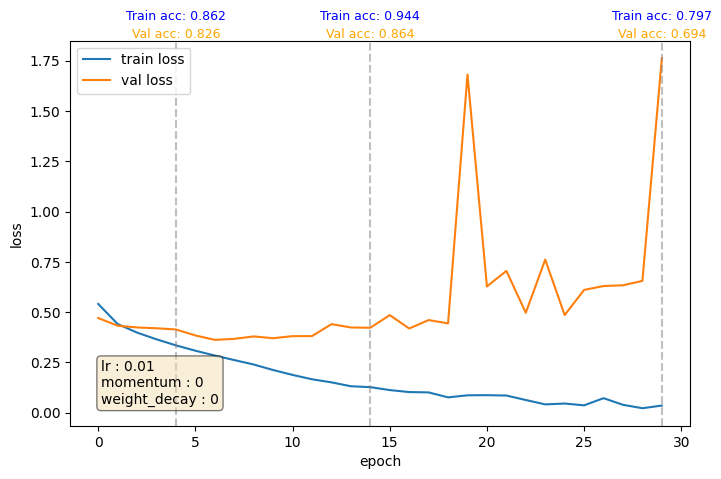

In [20]:
baseline_plot = plot_train_val_losses(
    train_losses=train_losses,
    val_losses=validation_losses,
    train_acc=train_accuracies_base,
    val_acc=val_accuracies_base,
    params={"lr": 1e-2, "momentum": 0, "weight_decay": 0},
)
# plt.savefig("imgs/{inital_model_train}.png", baseline_plot)
baseline_plot

Eeverything works. The model is overfitting and seems to be diverging somewhat on the validation loss. Let's define hyperparameters to find a better model

In [24]:
# params to try, this took too long!
# learning_rate_ls = [1e-3, 5e-3, 1e-2]
# momentum_ls = [0.0, 0.5, 0.9]
# weight_decay_ls = [0.0, 1e-4, 1e-3, 1e-2]

# more suitable
learning_rate_ls = [1e-3, 1e-2]
momentum_ls = [0.5, 0.9]
weight_decay_ls = [1e-4, 1e-2]

# only for dropout model
dropout_rate_ls = [0.2, 0.4]  # wanted to try 0.8 to see the effect

# i would like more, but again time...
MAX_EPOCHS = 30

models = [
    MyMLPBaseLine,
    MyMLPDeep,
    MyMLPWide,
    MyMLPDropout
]

In [25]:
class ModelOutcome:
    def __init__(
        self,
        train_losses: list,
        val_losses: list,
        params: dict,
        train_accuracies: list[float],
        validation_accuracies: list[float],
        model_path: Path,
    ):
        self.train_losses = train_losses
        self.val_losses = val_losses

        self.params = params

        self.train_accuracies = train_accuracies
        self.validation_accuracies = validation_accuracies

        self.model_path = model_path

    def to_dict(self) -> dict:
        return {
            "train_losses": self.train_losses,
            "val_losses": self.val_losses,
            "params": self.params,
            "train_accuracies": self.train_accuracies,
            "validation_accuracies": self.validation_accuracies,
            "model_path": str(self.model_path) if self.model_path else None,
        }

    @staticmethod
    def from_dict(d: dict):
        return ModelOutcome(
            train_losses=d["train_losses"],
            val_losses=d["val_losses"],
            params=d["params"],
            train_accuracies=d["train_accuracies"],
            validation_accuracies=d["validation_accuracies"],
            model_path=Path(d["model_path"]) if d.get("model_path") else None,
        )

In [26]:
def make_model_hash(model, params):
    """Chatgpt"""
    buffer = io.BytesIO()
    torch.save(model.state_dict(), buffer)
    buffer.seek(0)
    model_bytes = buffer.read()
    param_bytes = str(sorted(params.items())).encode()
    combined = model_bytes + param_bytes
    return hashlib.sha256(combined).hexdigest()[:10]

In [24]:
all_model_outcomes: dict[list[ModelOutcome]] = {}

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

for model_class in models:
    params_and_losses: list[ModelOutcome] = []

    if model_class == MyMLPDropout:
        perms = product(learning_rate_ls, momentum_ls, weight_decay_ls, dropout_rate_ls)
        model_count = (
            len(learning_rate_ls)
            * len(momentum_ls)
            * len(weight_decay_ls)
            * len(dropout_rate_ls)
        )
    else:
        perms = product(learning_rate_ls, momentum_ls, weight_decay_ls)
        model_count = len(learning_rate_ls) * len(momentum_ls) * len(weight_decay_ls)

    for index, hyperparams in enumerate(perms):
        torch.manual_seed(SEED)
        if model_class == MyMLPDropout:
            learning_rate, momentum, weight_decay, dropout_rate = hyperparams
            model = model_class(dropout_rate=dropout_rate).to(device)
        else:
            learning_rate, momentum, weight_decay = hyperparams
            model = model_class().to(device)

        optimizer = optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=momentum,
            weight_decay=weight_decay,
        )

        loss_fn = nn.CrossEntropyLoss()

        if model_class == MyMLPDropout:
            params["dropout_rate"] = dropout_rate

        train_losses, validation_losses, train_accuracies, val_accuracies = train(
            n_epochs=MAX_EPOCHS,
            optimizer=optimizer,
            model=model,
            loss_fn=loss_fn,
            train_loader=train_loader,
            validation_loader=val_loader,
        )
        print(f"Trained {index} of {model_count} model permuations")

        params = {
            "model": model.name(),
            "learning_rate": learning_rate,
            "momentum": momentum,
            "weight_decay": weight_decay,
        }

        model_hash = make_model_hash(model, params)
        model_path = models_dir / f"{model_hash}.pt"

        torch.save(model.state_dict(), model_path)

        model_outcome = ModelOutcome(
            train_losses=train_losses,
            val_losses=validation_losses,
            params=params,
            train_accuracies=train_accuracies,
            validation_accuracies=val_accuracies,
            model_path=model_path,
        )

        params_and_losses.append(model_outcome)

    print(f"Finished training {model.name()}")
    all_model_outcomes[model.name()] = params_and_losses

all_model_outcomes.keys()

13:20:44.716324  |  Epoch 1  |  Training loss 0.631
13:21:09.539013  |  Epoch 10  |  Training loss 0.388
13:21:36.835568  |  Epoch 20  |  Training loss 0.263
13:22:04.303027  |  Epoch 30  |  Training loss 0.140
Trained 0 of 8 model permuations
13:22:07.123639  |  Epoch 1  |  Training loss 0.632
13:22:31.748783  |  Epoch 10  |  Training loss 0.396
13:22:58.878809  |  Epoch 20  |  Training loss 0.286
13:23:26.005338  |  Epoch 30  |  Training loss 0.176
Trained 1 of 8 model permuations
13:23:28.715902  |  Epoch 1  |  Training loss 0.537
13:23:53.352911  |  Epoch 10  |  Training loss 0.193
13:24:20.560496  |  Epoch 20  |  Training loss 0.086
13:24:47.953379  |  Epoch 30  |  Training loss 0.025
Trained 2 of 8 model permuations
13:24:50.653506  |  Epoch 1  |  Training loss 0.539
13:25:15.229022  |  Epoch 10  |  Training loss 0.228
13:25:42.354064  |  Epoch 20  |  Training loss 0.142
13:26:09.456671  |  Epoch 30  |  Training loss 0.107
Trained 3 of 8 model permuations
13:26:12.155726  |  Epoc

dict_keys(['MyMLPBaseLine', 'MyMLPDeep', 'MyMLPWide', 'MyMLPDropout'])

In [27]:
# save
output_path = Path("data/saved/model_outcomes.json")

In [ ]:
# if not output_path.exists():
json.dump(
    {k: [m.to_dict() for m in v] for k, v in all_model_outcomes.items()},
    output_path.open("w"),
)

In [28]:
# load
loaded_json = json.load(Path(output_path).open("r"))
all_model_outcomes = {
    k: [ModelOutcome.from_dict(m) for m in v] for k, v in loaded_json.items()
}

In [29]:
def plot_all_runs(runs: list, model_title: str):
    n = len(runs)
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    fig.suptitle(f"All runs for model type {model_title}")

    for ax, model_outcome in zip(axes, runs):
        plot_train_val_losses(
            train_losses=model_outcome.train_losses,
            val_losses=model_outcome.val_losses,
            train_acc=model_outcome.train_accuracies,
            val_acc=model_outcome.validation_accuracies,
            params=model_outcome.params,
            ax=ax,
        )

    for i in range(n, len(axes)):
        fig.delaxes(axes[i])

    fig.savefig(f"imgs/hyperparams_{model_title}.png")

    plt.tight_layout()
    plt.show()

In [30]:
all_model_outcomes

{'MyMLPBaseLine': [<__main__.ModelOutcome at 0x7f1af6d68cb0>,
 'MyMLPDeep': [<__main__.ModelOutcome at 0x7f1af6da7770>,
 'MyMLPWide': [<__main__.ModelOutcome at 0x7f1af6da67e0>,
 'MyMLPDropout': [<__main__.ModelOutcome at 0x7f1af6da5850>,
  <__main__.ModelOutcome at 0x7f1af6da5460>]}

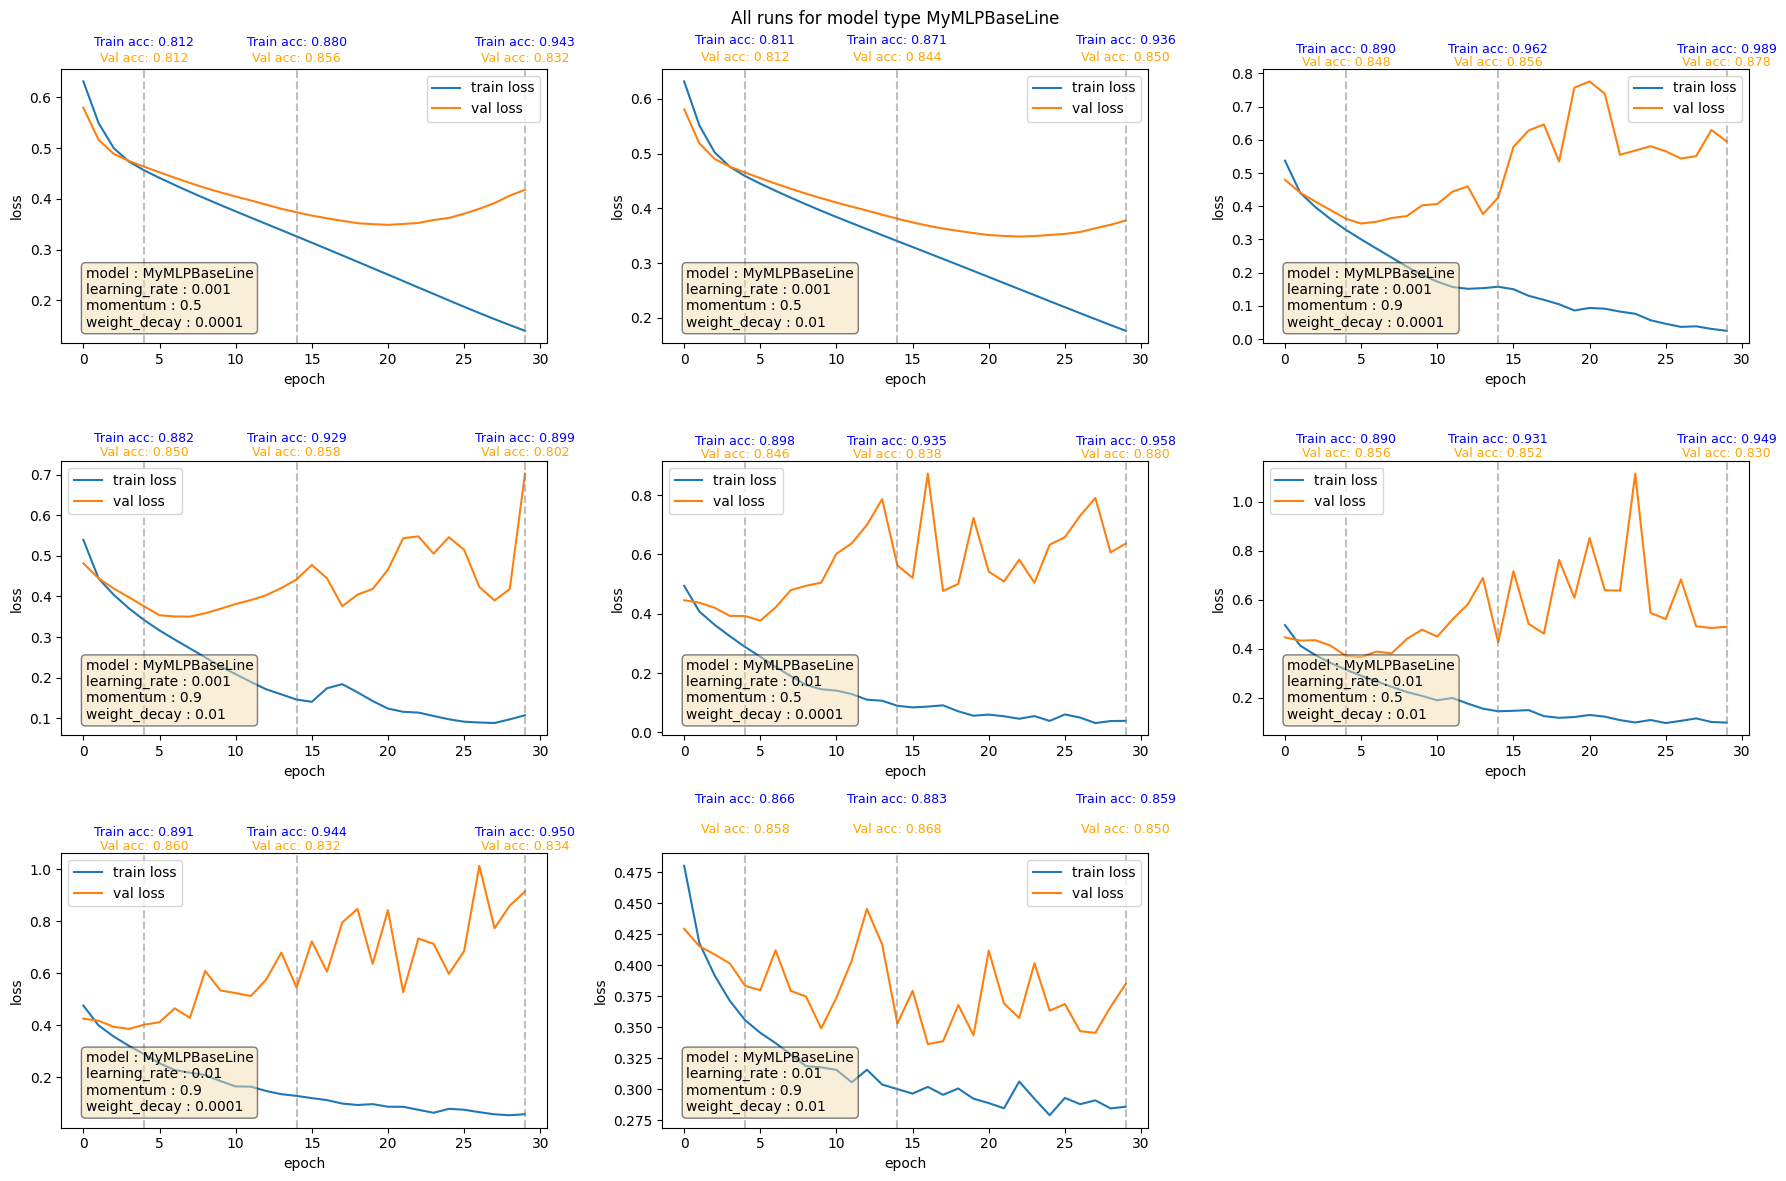

In [34]:
runs = all_model_outcomes["MyMLPBaseLine"]
plot_all_runs(runs, "MyMLPBaseLine")

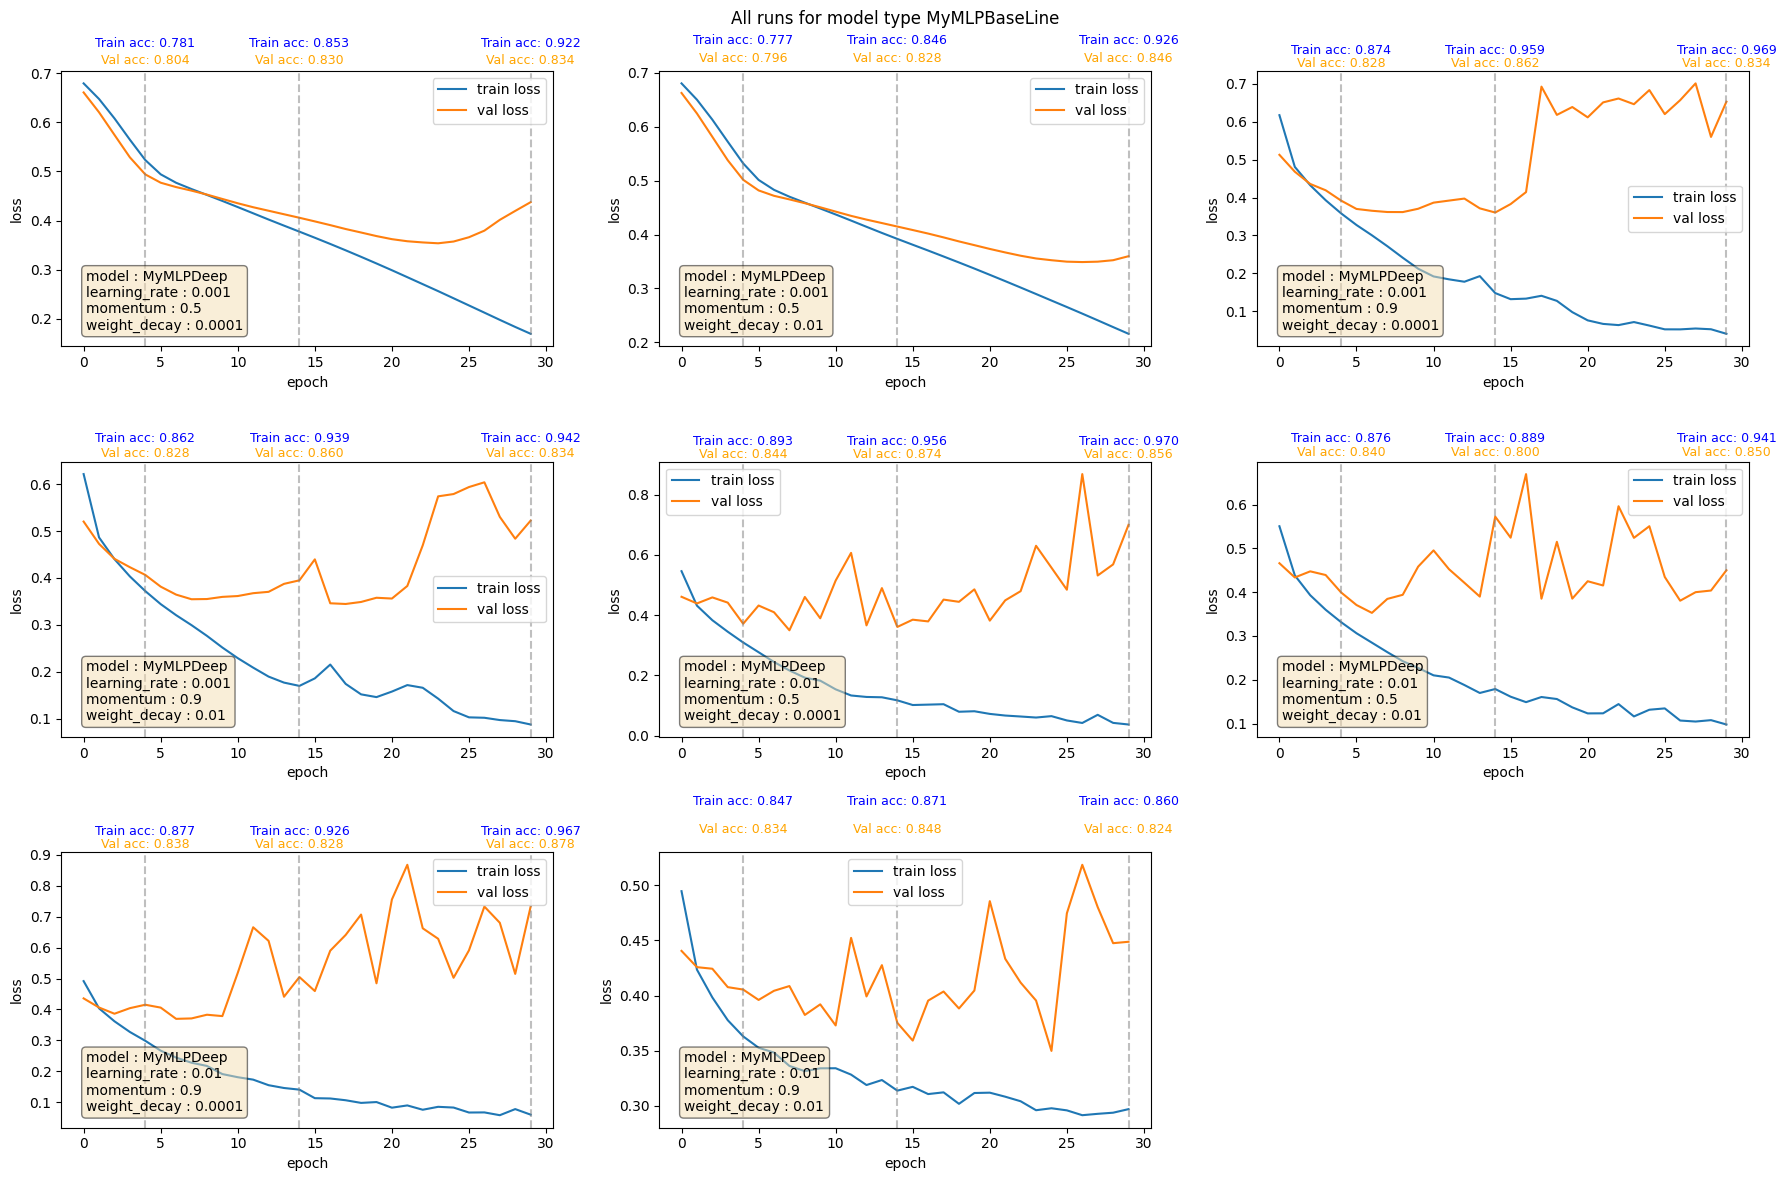

In [ ]:
runs = all_model_outcomes["MyMLPDeep"]
plot_all_runs(runs, "MyMLPDeep")

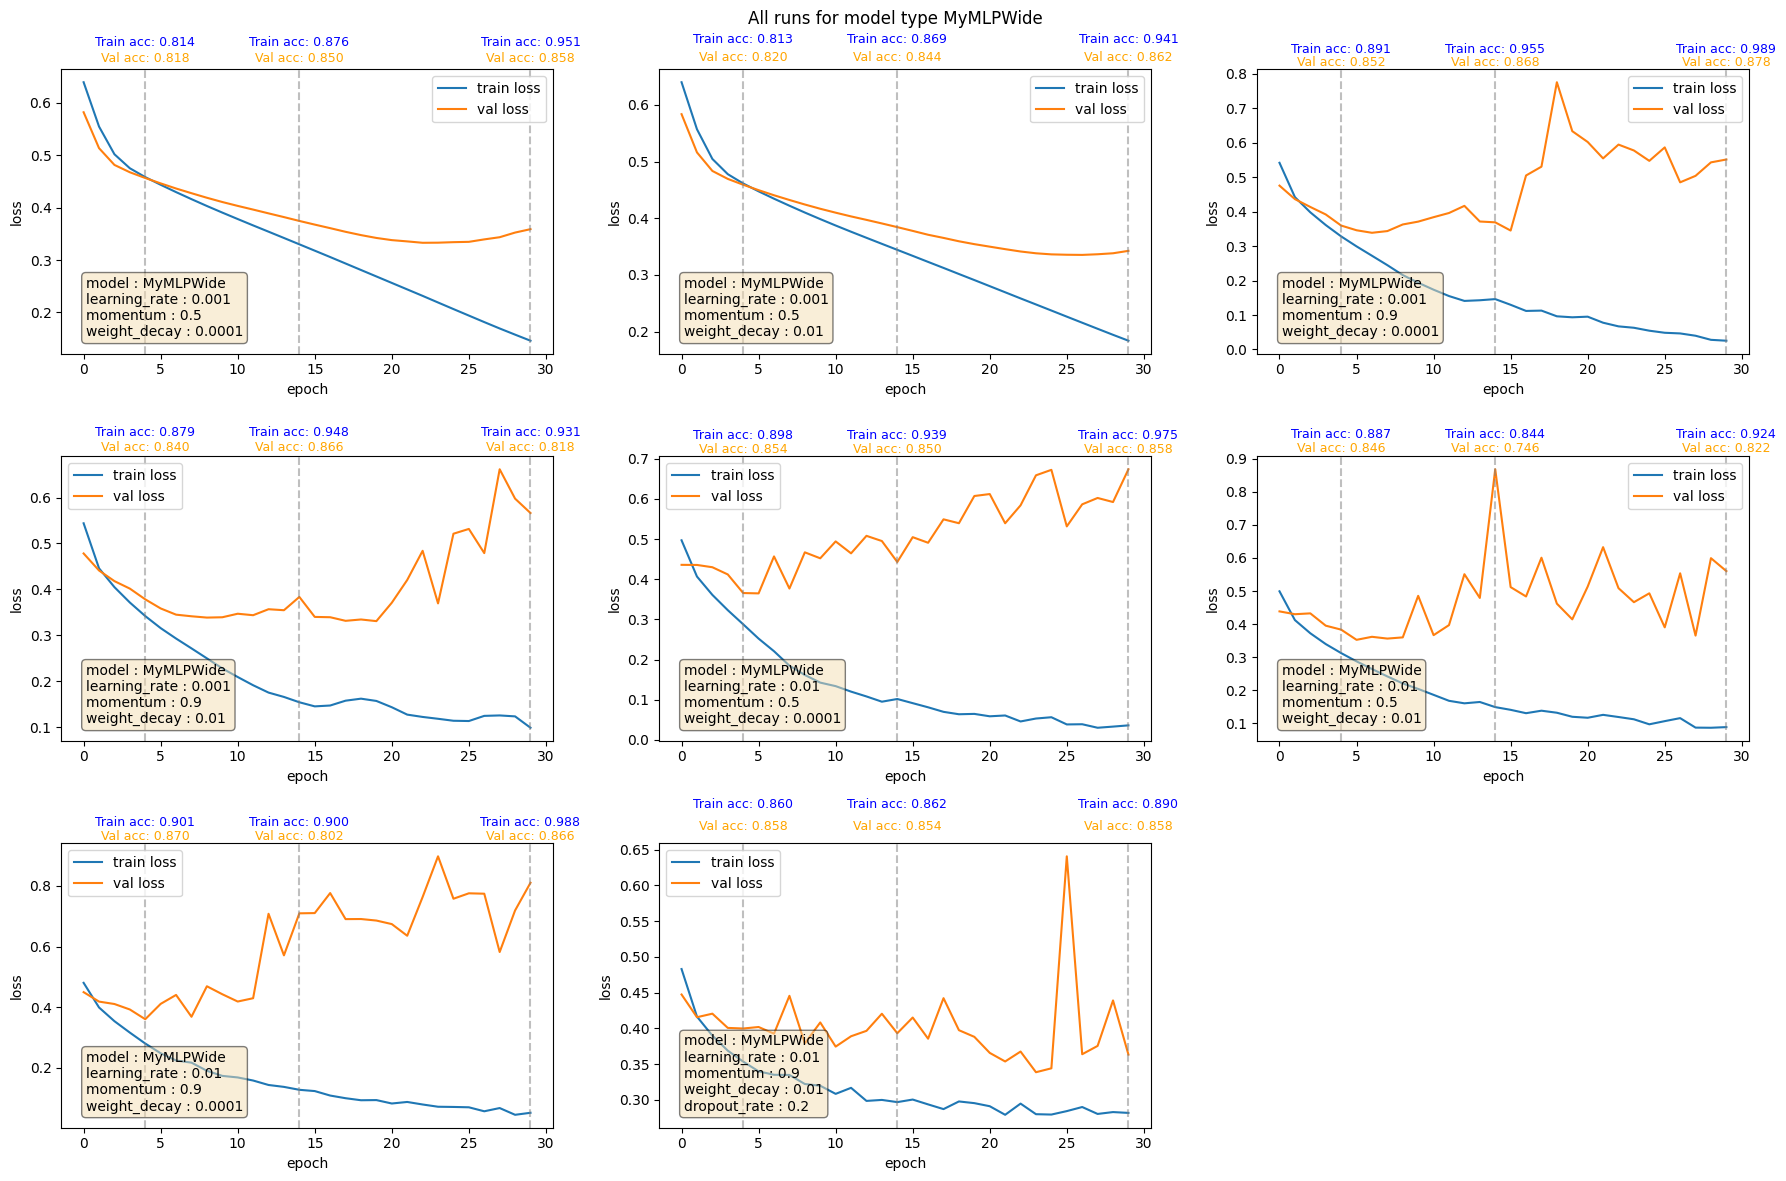

In [35]:
runs = all_model_outcomes["MyMLPWide"]
plot_all_runs(runs, "MyMLPWide")

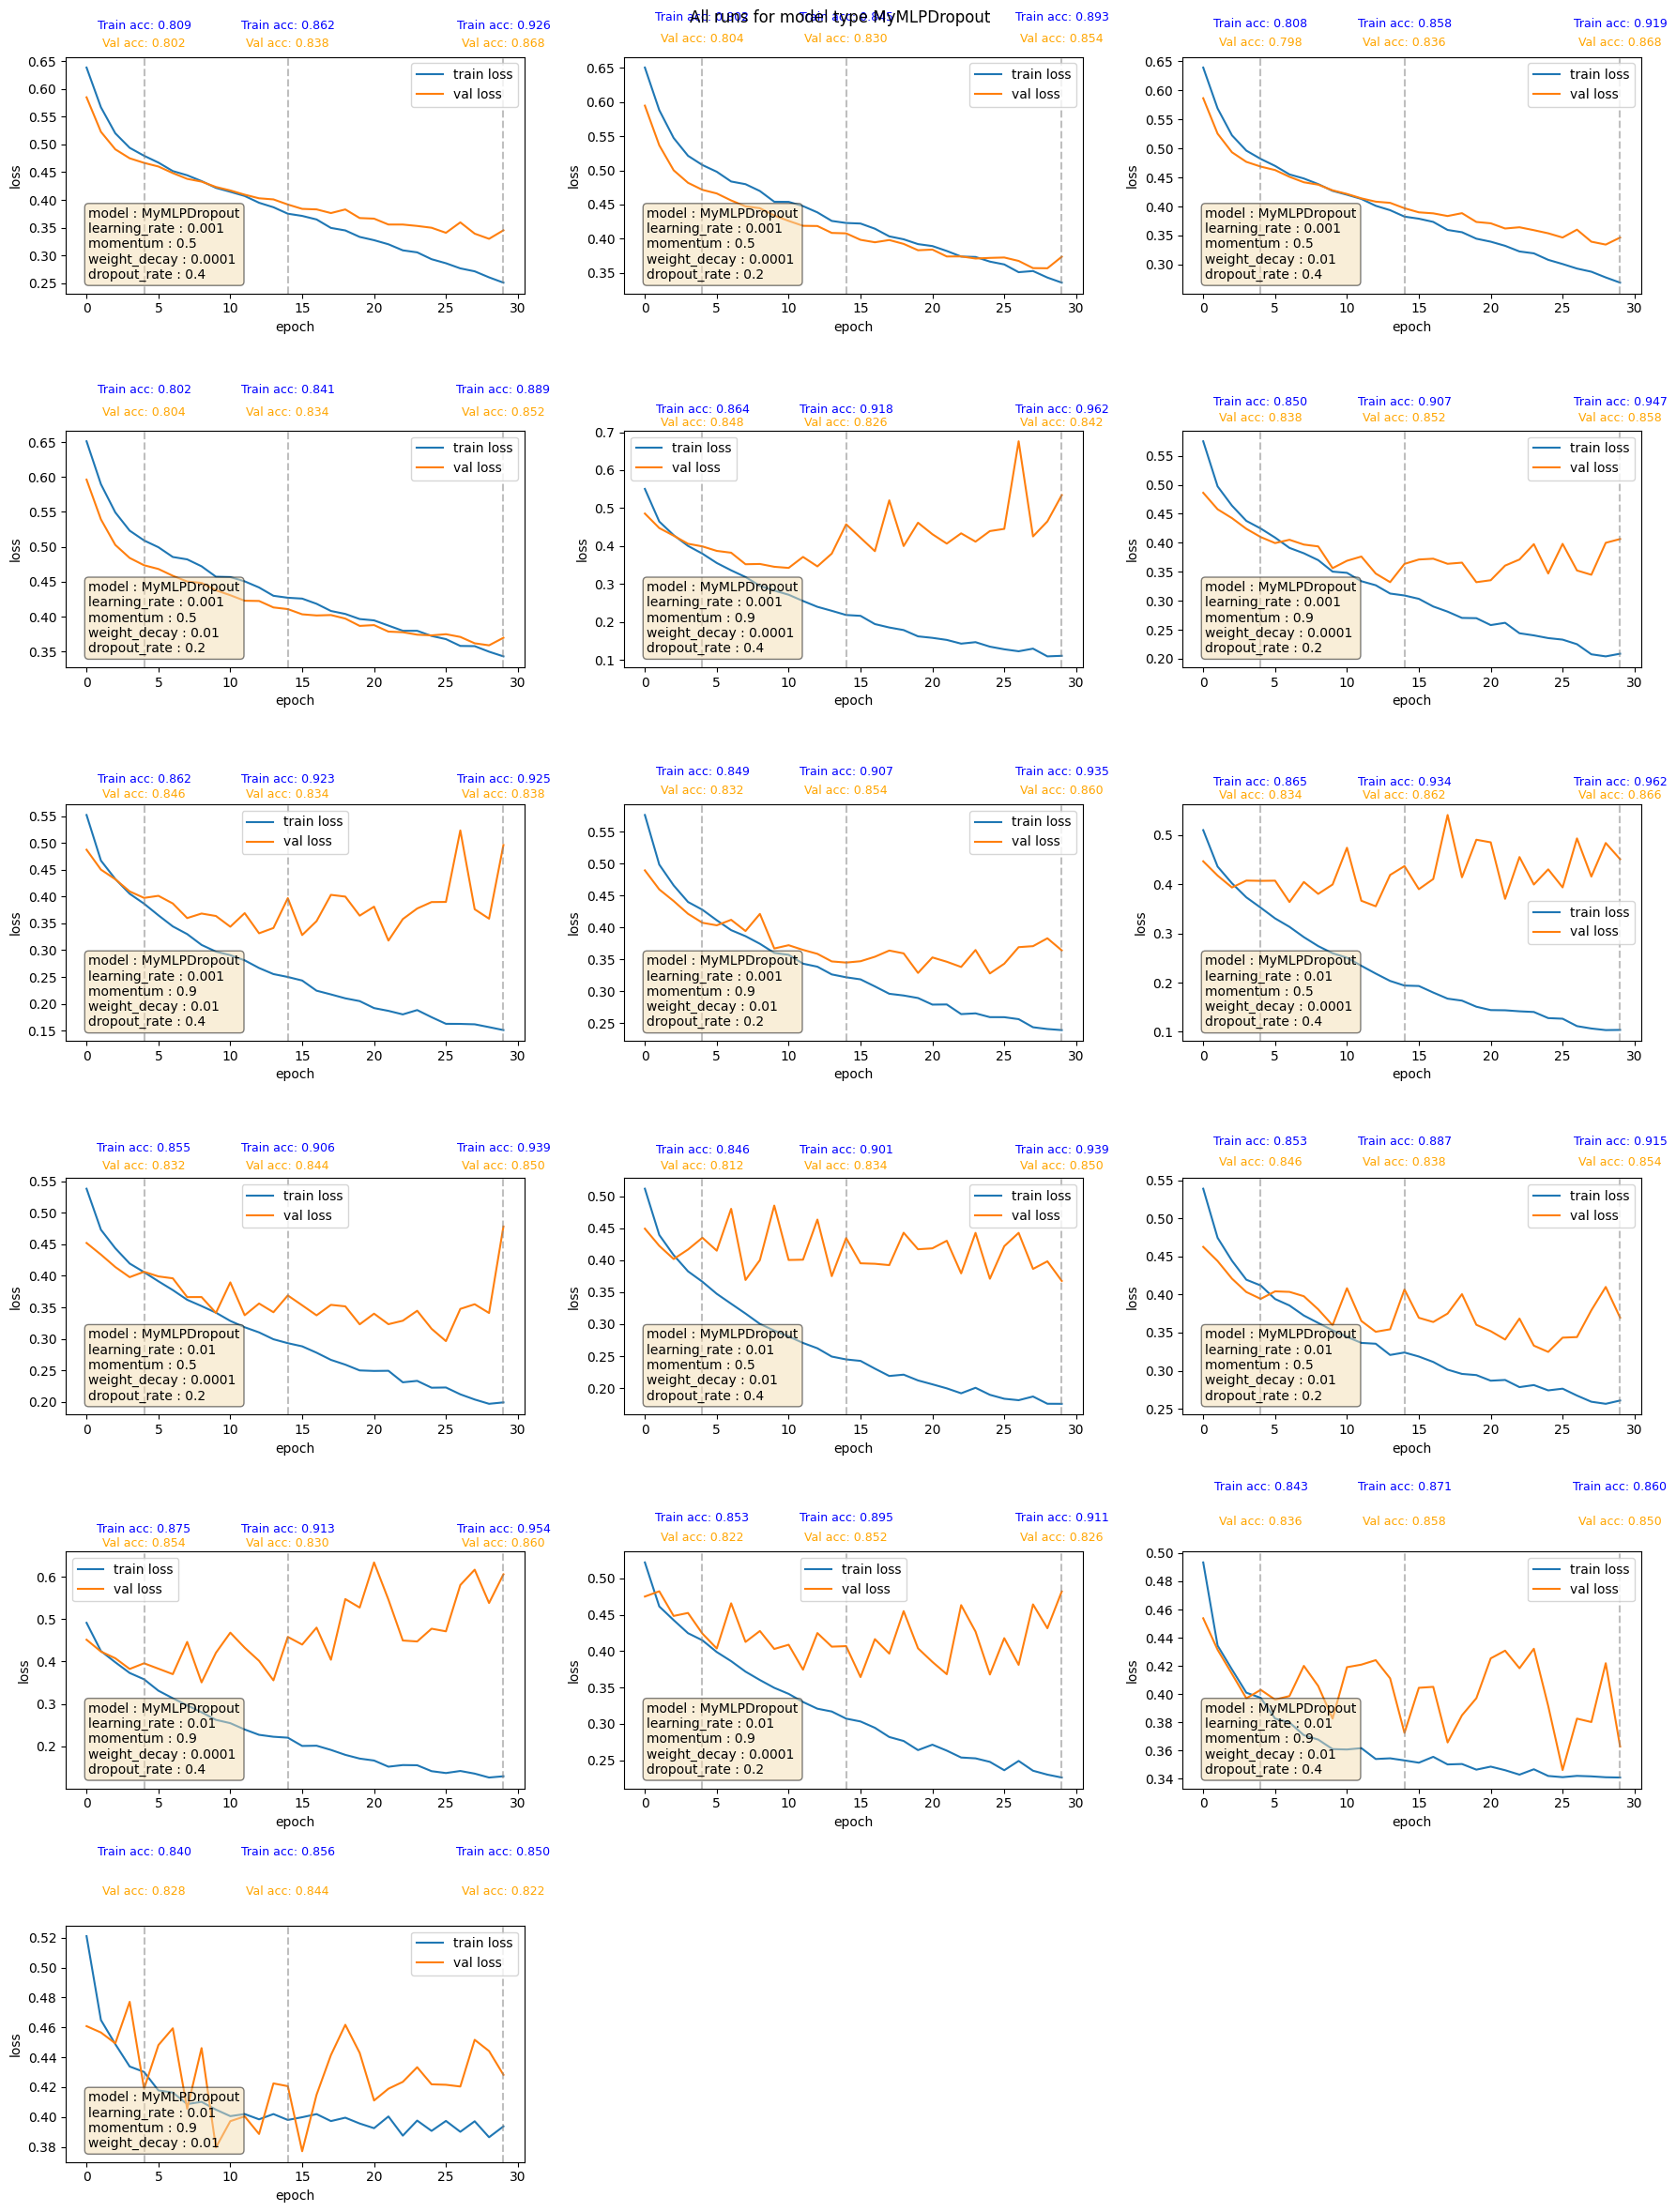

In [36]:
runs = all_model_outcomes["MyMLPDropout"]
plot_all_runs(runs, "MyMLPDropout")

In [ ]:
best_model_outcome = None
best_val_acc = -1.0

# TODO fix me
for model_name, runs in all_model_outcomes.items():
    for run in runs:
        val_accs = run.validation_accuracies
        if isinstance(val_accs, dict):
            val_acc_values = [v for v in val_accs.values()]
        else:
            val_acc_values = val_accs

        max_val_acc = max(val_acc_values)
        if max_val_acc > best_val_acc:
            best_val_acc = max_val_acc
            best_model_outcome = run

print(f"Best model: {best_model_outcome.params['model']}")
print(f"Best validation accuracy: {best_val_acc:.3f}")
print(f"Saved at: {best_model_outcome.model_path}")

Best model: MyMLPBaseLine
Best validation accuracy: 0.880
Saved at: models/0ec2b858aa.pt


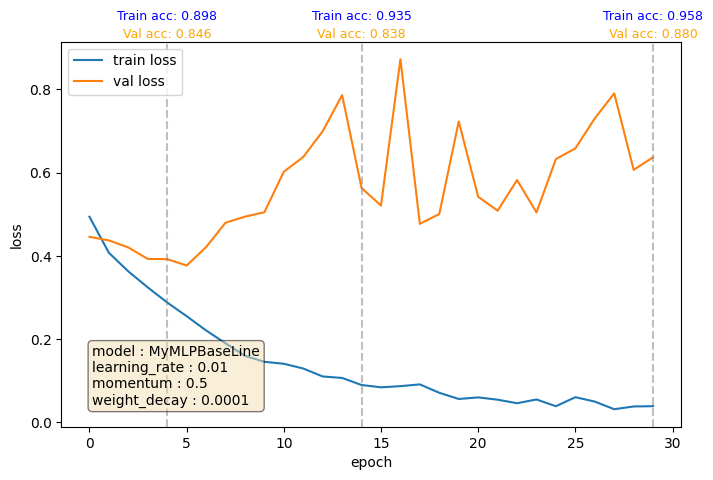

In [38]:
plot_train_val_losses(
    train_losses=best_model_outcome.train_losses,
    val_losses=best_model_outcome.val_losses,
    train_acc=best_model_outcome.train_accuracies,
    val_acc=best_model_outcome.validation_accuracies,
    params=best_model_outcome.params,
)
plt.show()


In [39]:
model_class_name = best_model_outcome.params["model"]
best_model = MyMLPBaseLine().to(device)
best_model.load_state_dict(torch.load(best_model_outcome.model_path))
best_model.eval()

MyMLPBaseLine(
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=2, bias=True)
)

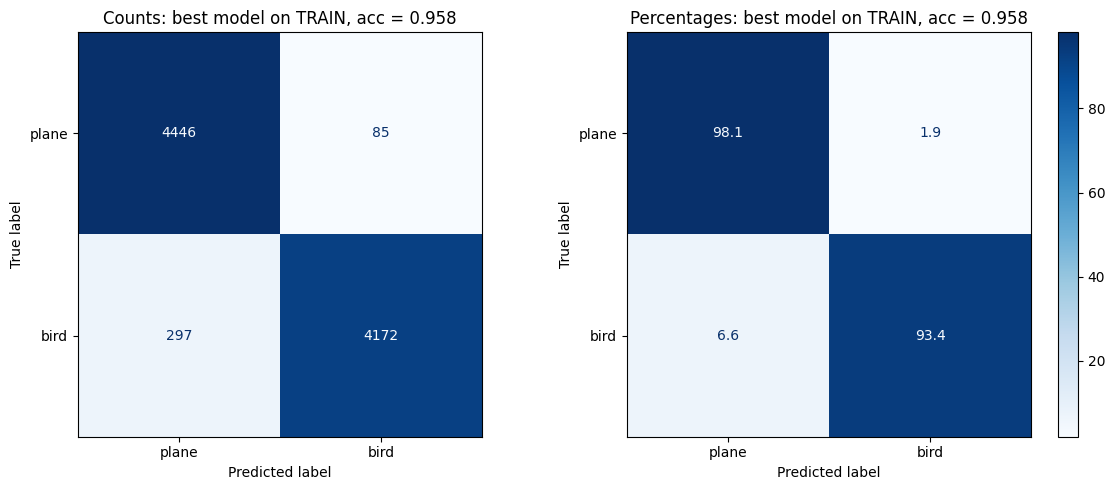

In [40]:
compute_confusion_matrix(best_model, train_loader, f"best model on TRAIN, acc = {float(best_model_outcome.train_accuracies["30"]):.3f}") # we pick epoch 30 since model was best here

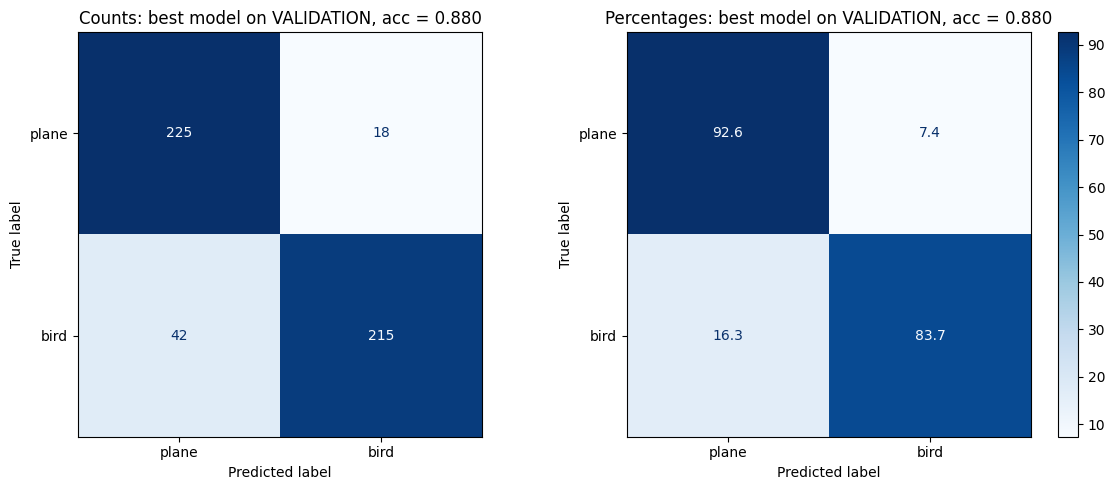

In [41]:
compute_confusion_matrix(best_model, val_loader, f"best model on VALIDATION, acc = {float(best_model_outcome.validation_accuracies["30"]):.3f}") # we pick epoch 30 since model was best here

In [42]:
test_accuracy = compute_accuracy(best_model, test_loader)
test_accuracy

0.854

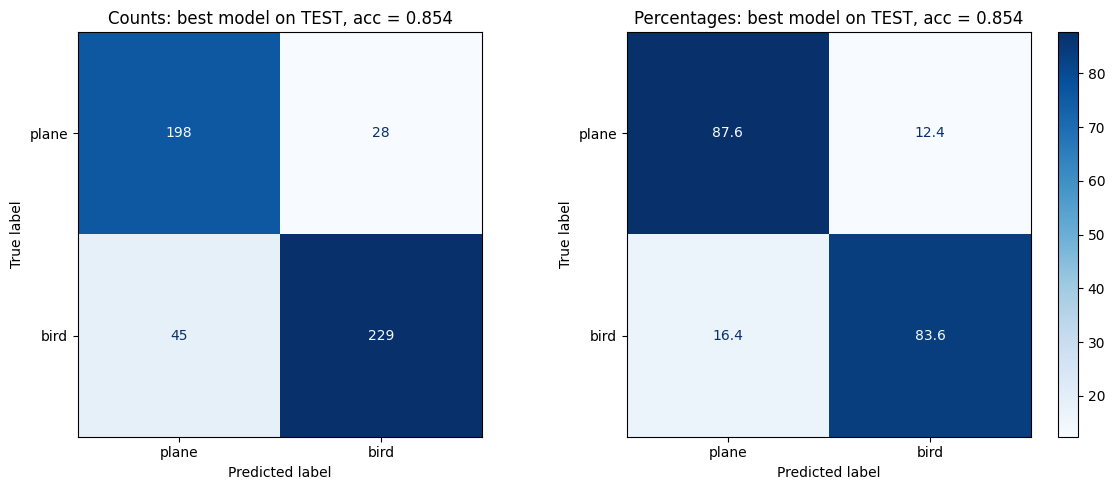

In [43]:
compute_confusion_matrix(best_model, test_loader, f"best model on TEST, acc = {test_accuracy}")

In [55]:
def get_misclassified_images(model, dataset):
    misclassified = []

    model.eval()
    with torch.no_grad():
        for imgs, labels in dataset:
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, dim=1)

            mis_idx = (predicted != labels).nonzero(as_tuple=True)[0]
            for idx in mis_idx:
                idx = idx.item()
                img = imgs[idx].cpu()
                true_label = labels[idx].item()
                pred_label = predicted[idx].item()
                misclassified.append((img, true_label, pred_label))

    return misclassified

In [60]:
def show_misclassified(misclassified_imgs, processor = None):
    n = len(misclassified_imgs)
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    def plot_one(img, true, pred, ax):
        if processor:
            img_disp = processor.unnormalize(img).permute(1, 2, 0).numpy()
        else:
            img_disp = img.squeeze().permute(1, 2, 0).numpy()

        img_disp = np.clip(img_disp, 0, 1)

        ax.imshow(img_disp)
        ax.set_title(f"True: {'plane' if true==0 else 'bird'} | Pred: {'plane' if pred==0 else 'bird'}")
        ax.axis("off")

    for ax, (img, true_label, pred_label) in zip(axes, misclassified_imgs):
        plot_one(img, true_label, pred_label, ax)

    # Remove unused axes
    for i in range(n, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    fig.savefig("imgs/wrong_images_test.png")
    plt.show()


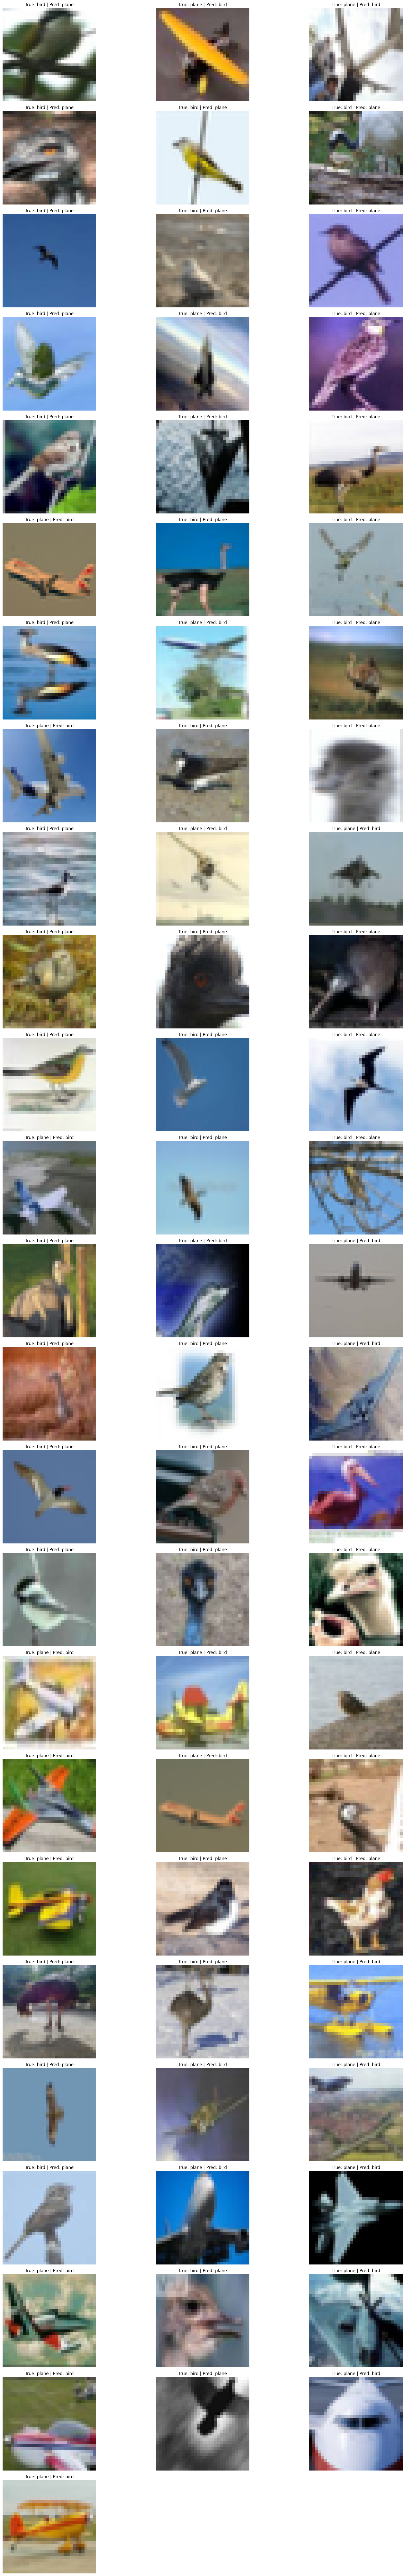

In [61]:
wrong_imgs = get_misclassified_images(best_model, dataset=test_loader)
show_misclassified(wrong_imgs, processor=processor)